In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
df = pd.read_csv("Delivery_Logistics.csv")

df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [3]:
print("Shape:", df.shape)
df.columns
df.info()
df.describe()

Shape: (25000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), in

,delivery_id,distance_km,package_weight_kg,delivery_rating,delivery_cost
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,3.666000,864.944579
std,7212.732314,86.409745,14.368663,1.149964,435.712593
min,250.990000,3.600000,0.670000,1.000000,95.667400
25%,6250.750000,75.900000,12.680000,3.000000,490.800000
50%,12500.500000,151.000000,25.145000,4.000000,867.535000
75%,18750.250000,224.900000,37.660000,5.000000,1237.910000
max,24750.010000,297.100000,49.520000,5.000000,1632.720600


In [4]:
missing_values = df.isnull().sum()
print(missing_values)

missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)


delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
dtype: int64
delivery_id            0.0
delivery_partner       0.0
package_type           0.0
vehicle_type           0.0
delivery_mode          0.0
region                 0.0
weather_condition      0.0
distance_km            0.0
package_weight_kg      0.0
delivery_time_hours    0.0
expected_time_hours    0.0
delayed                0.0
delivery_status        0.0
delivery_rating        0.0
delivery_cost          0.0
dtype: float64


In [5]:
duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


In [6]:
print(df.dtypes)

delivery_id            float64
delivery_partner        object
package_type            object
vehicle_type            object
delivery_mode           object
region                  object
weather_condition       object
distance_km            float64
package_weight_kg      float64
delivery_time_hours     object
expected_time_hours     object
delayed                 object
delivery_status         object
delivery_rating          int64
delivery_cost          float64
dtype: object


In [7]:
categorical_columns = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition",
    "delayed",
    "delivery_status"
]

for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts())


 delivery_partner
delivery_partner
xpressbees          2826
fedex               2818
dhl                 2802
ekart               2801
blue dart           2798
delhivery           2786
shadowfax           2736
ecom express        2722
amazon logistics    2711
Name: count, dtype: int64

 package_type
package_type
fragile items       2848
pharmacy            2810
documents           2805
automobile parts    2795
electronics         2792
clothing            2767
furniture           2746
cosmetics           2744
groceries           2693
Name: count, dtype: int64

 vehicle_type
vehicle_type
ev bike    4218
van        4187
scooter    4174
bike       4160
truck      4145
ev van     4116
Name: count, dtype: int64

 delivery_mode
delivery_mode
two day     6302
same day    6279
express     6233
standard    6186
Name: count, dtype: int64

 region
region
west       5095
central    5060
south      4977
north      4949
east       4919
Name: count, dtype: int64

 weather_condition
weather_condition


In [8]:
numerical_columns = [
    "distance_km",
    "package_weight_kg",
    "delivery_time_hours",
    "expected_time_hours",
    "delivery_rating",
    "delivery_cost"
]

df[numerical_columns].describe()

,distance_km,package_weight_kg,delivery_rating,delivery_cost
count,25000.000000,25000.000000,25000.000000,25000.000000
mean,150.390436,25.145898,3.666000,864.944579
std,86.409745,14.368663,1.149964,435.712593
min,3.600000,0.670000,1.000000,95.667400
25%,75.900000,12.680000,3.000000,490.800000
50%,151.000000,25.145000,4.000000,867.535000
75%,224.900000,37.660000,5.000000,1237.910000
max,297.100000,49.520000,5.000000,1632.720600


In [10]:
for column in numerical_columns:
    # Check if the column's dtype is numerical (e.g., int, float)
    if pd.api.types.is_numeric_dtype(df[column]):
        print(column, "negative values:", (df[column] < 0).sum())
    else:
        print(f"Skipping non-numeric column '{column}' for negative value check.")

distance_km negative values: 0
package_weight_kg negative values: 0
Skipping non-numeric column 'delivery_time_hours' for negative value check.
Skipping non-numeric column 'expected_time_hours' for negative value check.
delivery_rating negative values: 0
delivery_cost negative values: 0


In [11]:
def find_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))

    return outliers

In [13]:
for column in numerical_columns:
    # Check if the column's dtype is numerical before finding outliers
    if pd.api.types.is_numeric_dtype(df[column]):
        find_outliers(column)
    else:
        print(f"Skipping non-numeric column '{column}' for outlier detection.")

Column: distance_km
Q1: 75.9
Q3: 224.9
IQR: 149.0
Lower Bound: -147.6
Upper Bound: 448.4
Number of Outliers: 0
Column: package_weight_kg
Q1: 12.68
Q3: 37.66
IQR: 24.979999999999997
Lower Bound: -24.79
Upper Bound: 75.13
Number of Outliers: 0
Skipping non-numeric column 'delivery_time_hours' for outlier detection.
Skipping non-numeric column 'expected_time_hours' for outlier detection.
Column: delivery_rating
Q1: 3.0
Q3: 5.0
IQR: 2.0
Lower Bound: 0.0
Upper Bound: 8.0
Number of Outliers: 0
Column: delivery_cost
Q1: 490.8
Q3: 1237.91
IQR: 747.1100000000001
Lower Bound: -629.8650000000002
Upper Bound: 2358.5750000000003
Number of Outliers: 0


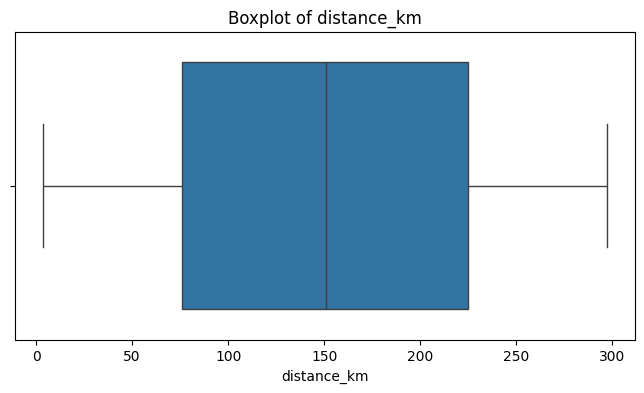

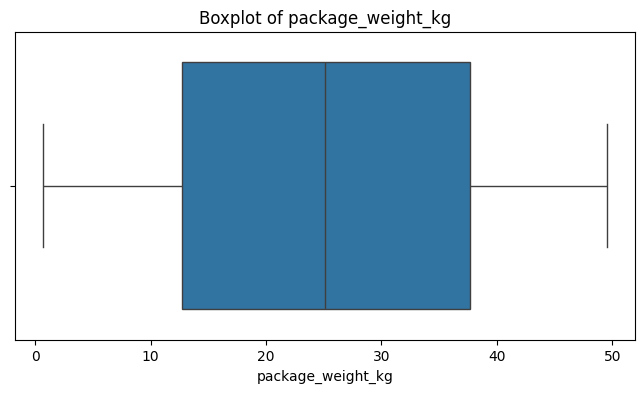

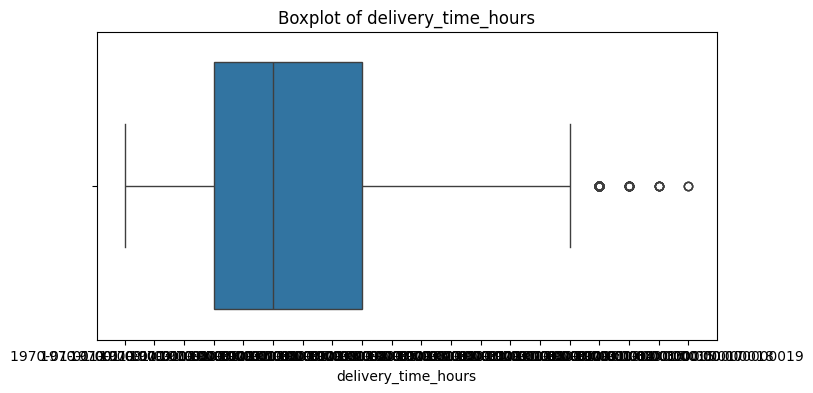

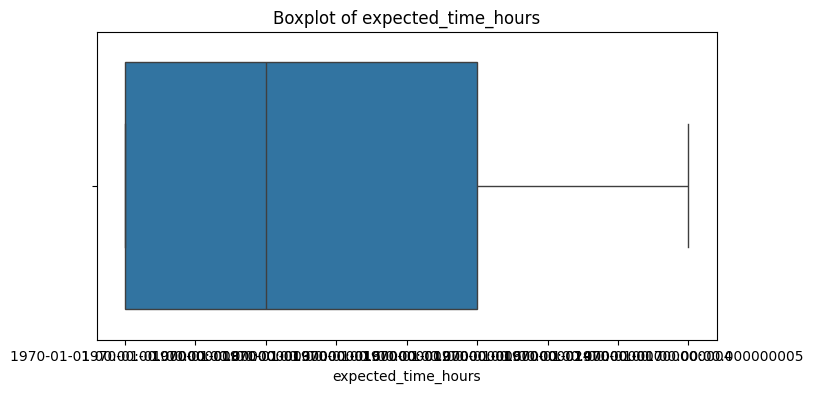

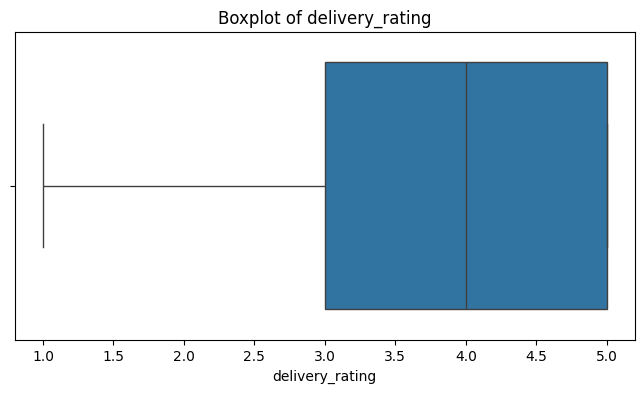

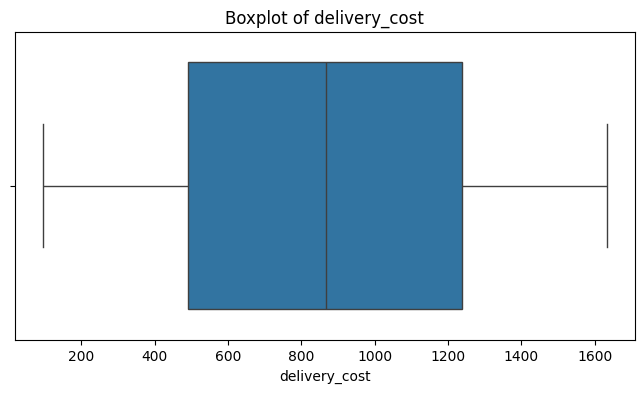

In [14]:
for column in numerical_columns:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

In [15]:
Q1 = df["delivery_cost"].quantile(0.25)
Q3 = df["delivery_cost"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["delivery_cost"] < lower) |
    (df["delivery_cost"] > upper)
]

outliers.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost


In [17]:
# Convert delivery time columns to numeric
df["delivery_time_hours"] = pd.to_numeric(
    df["delivery_time_hours"], errors="coerce"
)

df["expected_time_hours"] = pd.to_numeric(
    df["expected_time_hours"], errors="coerce"
)

# Calculate delay
df["delay_hours"] = (
    df["delivery_time_hours"] -
    df["expected_time_hours"]
)

df[[
    "delivery_time_hours",
    "expected_time_hours",
    "delay_hours"
]].head()

,delivery_time_hours,expected_time_hours,delay_hours
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN


In [18]:
df[[
    "delivery_time_hours",
    "expected_time_hours"
]].isnull().sum()

,0
delivery_time_hours,25000
expected_time_hours,25000


In [19]:
print(df["delivery_time_hours"].head(10).to_list())
print(df["expected_time_hours"].head(10).to_list())
print(df["delivery_time_hours"].dtype)
print(df["expected_time_hours"].dtype)

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
float64
float64


In [20]:
df = pd.read_csv("Delivery_Logistics.csv")

In [21]:
print(df["delivery_time_hours"].head(10).to_list())
print(df["expected_time_hours"].head(10).to_list())

['1970-01-01 00:00:00.000000008', '1970-01-01 00:00:00.000000002', '1970-01-01 00:00:00.000000010', '1970-01-01 00:00:00.000000006', '1970-01-01 00:00:00.000000009', '1970-01-01 00:00:00.000000004', '1970-01-01 00:00:00.000000006', '1970-01-01 00:00:00.000000004', '1970-01-01 00:00:00.000000005', '1970-01-01 00:00:00.000000003']
['1970-01-01 00:00:00.000000008', '1970-01-01 00:00:00.000000003', '1970-01-01 00:00:00.000000016', '1970-01-01 00:00:00.000000008', '1970-01-01 00:00:00.000000016', '1970-01-01 00:00:00.000000002', '1970-01-01 00:00:00.000000008', '1970-01-01 00:00:00.000000008', '1970-01-01 00:00:00.000000008', '1970-01-01 00:00:00.000000008']


In [22]:
# Convert the datetime-like strings to datetime
df["delivery_time_hours"] = pd.to_datetime(
    df["delivery_time_hours"]
)

df["expected_time_hours"] = pd.to_datetime(
    df["expected_time_hours"]
)

# Extract the nanosecond component
df["delivery_time_hours"] = (
    df["delivery_time_hours"].dt.nanosecond
)

df["expected_time_hours"] = (
    df["expected_time_hours"].dt.nanosecond
)

# Calculate delay
df["delay_hours"] = (
    df["delivery_time_hours"] -
    df["expected_time_hours"]
)

df[[
    "delivery_time_hours",
    "expected_time_hours",
    "delay_hours"
]].head(10)

,delivery_time_hours,expected_time_hours,delay_hours
0,8,8,0
1,2,3,-1
2,10,16,-6
3,6,8,-2
4,9,16,-7
5,4,2,2
6,6,8,-2
7,4,8,-4
8,5,8,-3
9,3,8,-5


In [23]:
df["delay_status"] = np.where(
    df["delay_hours"] > 0,
    "Delayed",
    "On Time"
)

df["delay_status"].value_counts()

,count
delay_status,
On Time,19534
Delayed,5466


In [24]:
df[["delay_hours", "delay_status"]].head(10)

,delay_hours,delay_status
0,0,On Time
1,-1,On Time
2,-6,On Time
3,-2,On Time
4,-7,On Time
5,2,Delayed
6,-2,On Time
7,-4,On Time
8,-3,On Time
9,-5,On Time


In [25]:
delay_counts = df["delay_status"].value_counts()

print(delay_counts)

delay_status
On Time    19534
Delayed     5466
Name: count, dtype: int64


In [26]:
delay_percentage = df["delay_status"].value_counts(normalize=True) * 100

print(delay_percentage)

delay_status
On Time    78.136
Delayed    21.864
Name: proportion, dtype: float64


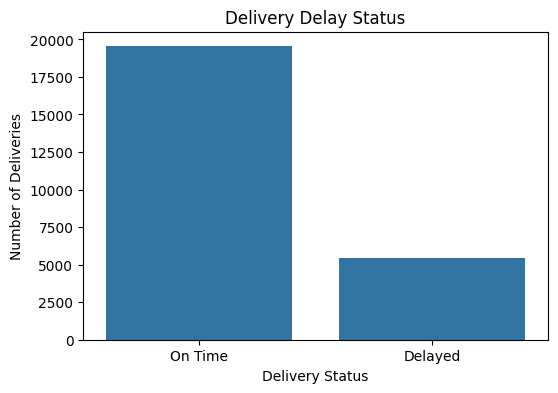

In [27]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="delay_status")

plt.title("Delivery Delay Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")

plt.show()

In [28]:
categorical_columns = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition",
    "delivery_status"
]

for column in categorical_columns:
    print("\n" + "="*40)
    print(column)
    print(df[column].value_counts())


delivery_partner
delivery_partner
xpressbees          2826
fedex               2818
dhl                 2802
ekart               2801
blue dart           2798
delhivery           2786
shadowfax           2736
ecom express        2722
amazon logistics    2711
Name: count, dtype: int64

package_type
package_type
fragile items       2848
pharmacy            2810
documents           2805
automobile parts    2795
electronics         2792
clothing            2767
furniture           2746
cosmetics           2744
groceries           2693
Name: count, dtype: int64

vehicle_type
vehicle_type
ev bike    4218
van        4187
scooter    4174
bike       4160
truck      4145
ev van     4116
Name: count, dtype: int64

delivery_mode
delivery_mode
two day     6302
same day    6279
express     6233
standard    6186
Name: count, dtype: int64

region
region
west       5095
central    5060
south      4977
north      4949
east       4919
Name: count, dtype: int64

weather_condition
weather_condition
foggy 

In [29]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    df[numerical_columns]
)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=numerical_columns
)

scaled_df.head()

,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delivery_rating,delivery_cost
0,1.696713,1.518202,0.557794,-0.675720,-0.57916,1.762151
1,-0.703528,1.548129,-1.352503,-1.337194,1.16006,-0.515888
2,1.424747,0.121385,1.194560,0.382639,0.29045,1.338582
3,1.380770,-0.866897,-0.078972,-0.675720,-0.57916,1.426715
4,1.230321,0.826405,0.876177,0.382639,0.29045,1.215540


In [30]:
print("Final Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Final Shape: (25000, 17)

Missing Values:
delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
delay_hours            0
delay_status           0
dtype: int64

Duplicates:
0

Data Types:
delivery_id            float64
delivery_partner        object
package_type            object
vehicle_type            object
delivery_mode           object
region                  object
weather_condition       object
distance_km            float64
package_weight_kg      float64
delivery_time_hours      int32
expected_time_hours      int32
delayed                 object
delivery_status         object
delivery_rating          int64
delivery_cost          float64
delay_hours              in

In [32]:
df.to_csv(
    "cleaned_delivery_logistics.csv",
    index=False
)